# Exploratory Data Analysis (EDA)
 
## 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/online_retail.csv')
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Executive Summary: Behavioral Insights
Refined analysis focusing on Product Diversity and Rolling Momentum as lead conversion indicators.


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 3. Missing Value Analysis

In [3]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentages = (missing_values / len(df)) * 100
pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentages}).sort_values('Percentage', ascending=False)

,Missing Values,Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
InvoiceNo,0,0.000000
StockCode,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


## 4.Channel Distribution

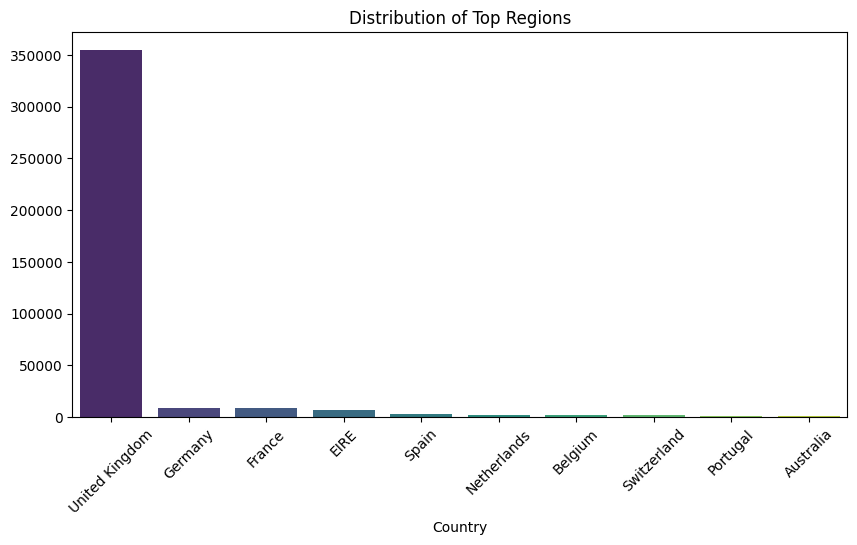

In [4]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]

plt.figure(figsize=(10, 5))
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Distribution of Top Regions')
plt.xticks(rotation=45)
plt.show()

## 5. Time-based Interaction Analysis

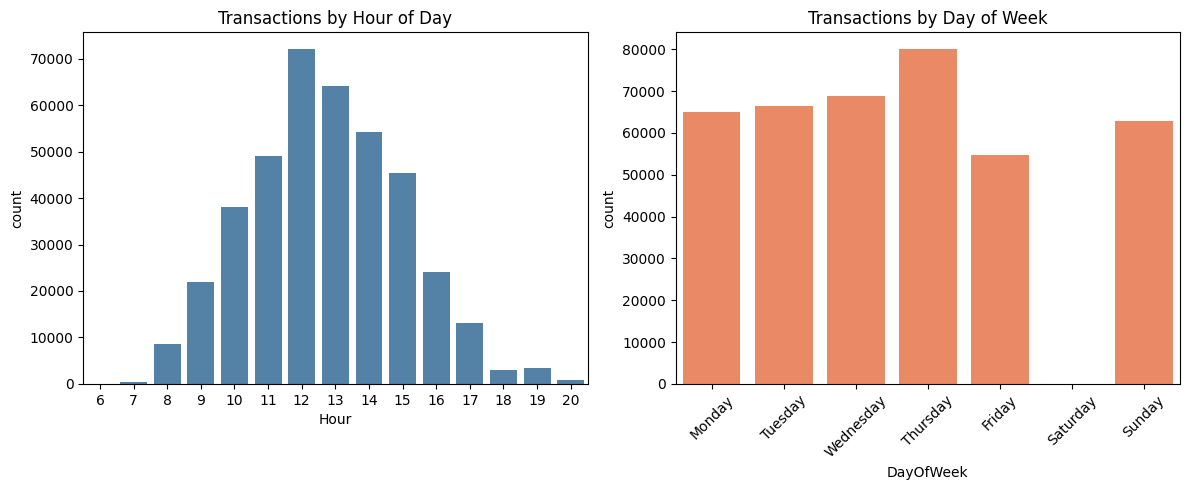

In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Hour', color='steelblue')
plt.title('Transactions by Hour of Day')

plt.subplot(1, 2, 2)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='DayOfWeek', order=days_order, color='coral')
plt.title('Transactions by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Initial Insights & Data Cleaning Prep

In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Hour
count,397924.000000,397924,397924.000000,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171,12.728247
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,6.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,11.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,13.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,20.000000
std,180.420210,NaN,22.096788,1713.169877,2.273535


In [7]:
# Duplicate region analysis skipped.